**Import Libraries**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [49]:
!pip install shap

import shap

**Upload Dataset**

In [17]:
df = pd.read_csv("/content/bank.csv", sep=',')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


**Dataset Exploration**

Shape

In [21]:
print("Shape:", df.shape)

Shape: (11162, 17)


Info

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Missing values

In [19]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


Target distribution

In [18]:
print(df['deposit'].value_counts())

deposit
no     5873
yes    5289
Name: count, dtype: int64


**Data Visualization**

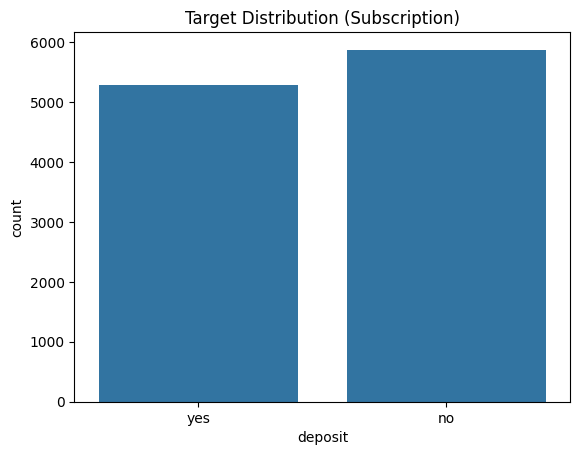

In [23]:
sns.countplot(x='deposit', data=df)
plt.title("Target Distribution (Subscription)")
plt.show()

**Encode Categorical Features**

In [24]:
data = df.copy()

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


**Split Features & Target**

In [26]:
X = data.drop('deposit', axis=1)
y = data['deposit']

**Train-Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

Logistic Regression

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train Classification Models**

Model 1: Logistic Regression

In [30]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

Model 2: Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

**Evaluation Metrics**

Confusion Matrix

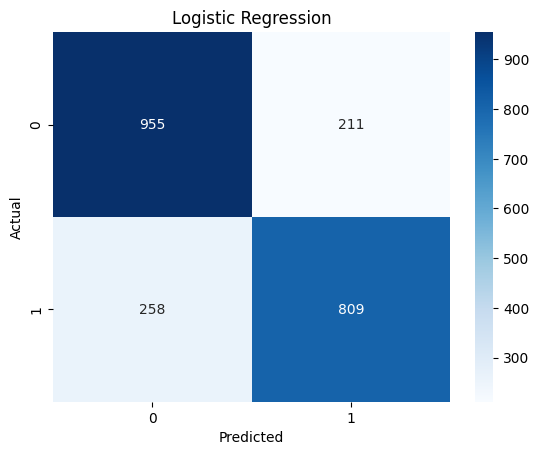

In [37]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_lr, "Logistic Regression")


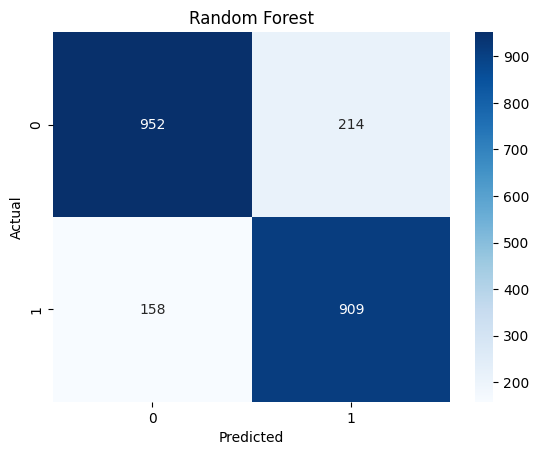

In [36]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
plot_cm(y_test, y_pred_rf, "Random Forest")

F1 Score

In [38]:
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

Logistic Regression F1: 0.7752755150934355
Random Forest F1: 0.8301369863013699


Classification Report

In [41]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



In [40]:
print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



ROC Curve

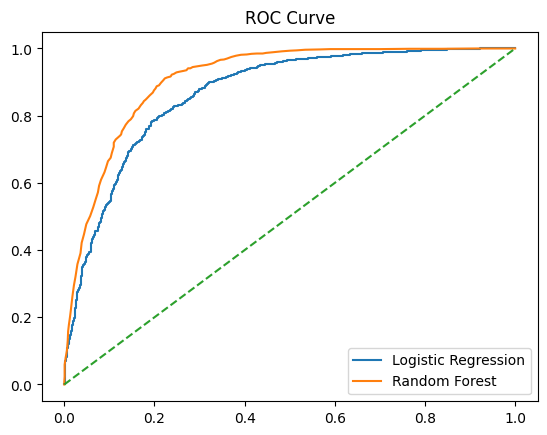

In [42]:
def plot_roc(y_test, y_prob, label):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label)

plt.figure()

plot_roc(y_test, y_prob_lr, "Logistic Regression")
plot_roc(y_test, y_prob_rf, "Random Forest")

plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.legend()
plt.show()

**Model Explainability**

In [43]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

SHAP Summary Plot

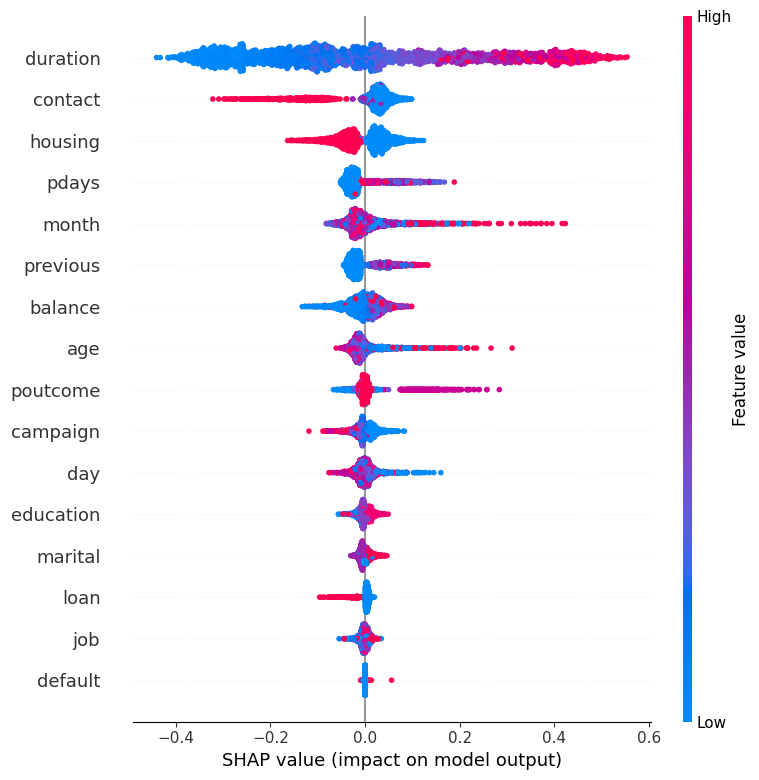

In [45]:
shap.summary_plot(shap_values[:, :, 1], X_test)

**Individual Predictions**


🔎 Explanation for Prediction 1


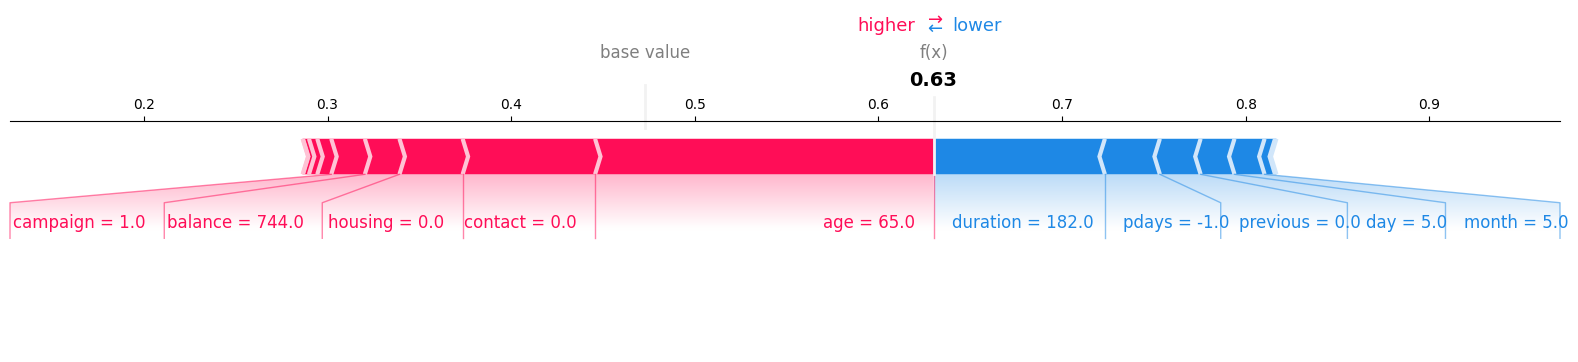


🔎 Explanation for Prediction 2


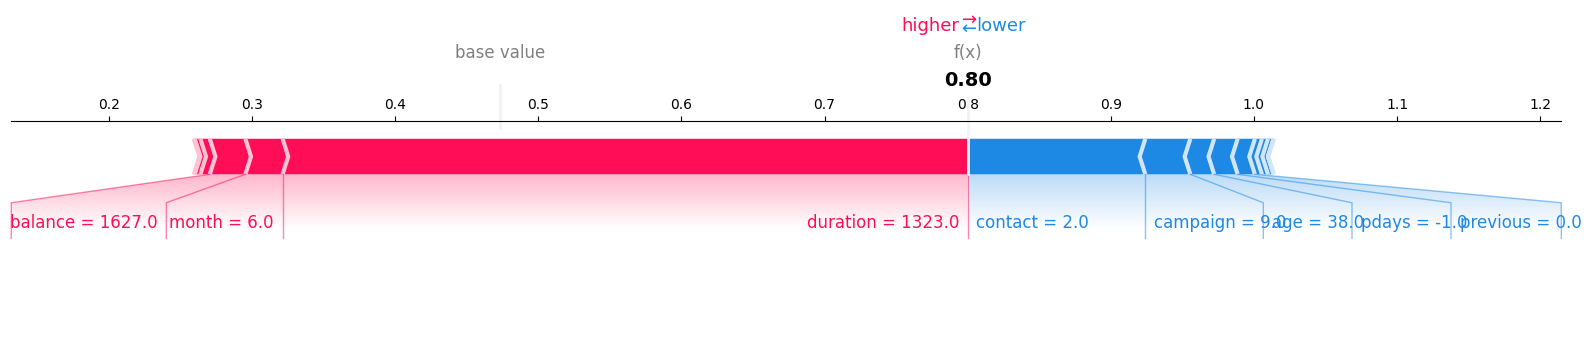


🔎 Explanation for Prediction 3


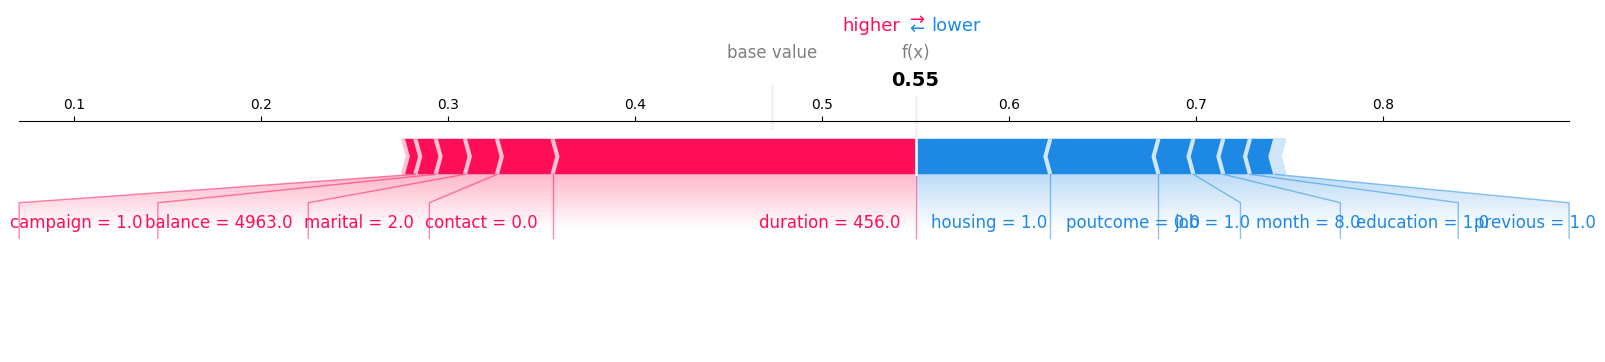


🔎 Explanation for Prediction 4


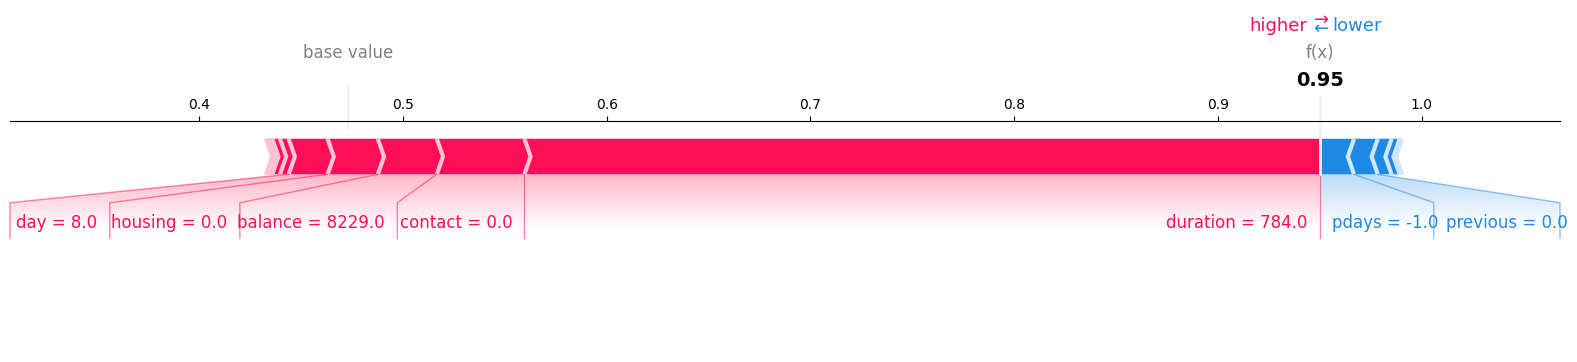


🔎 Explanation for Prediction 5


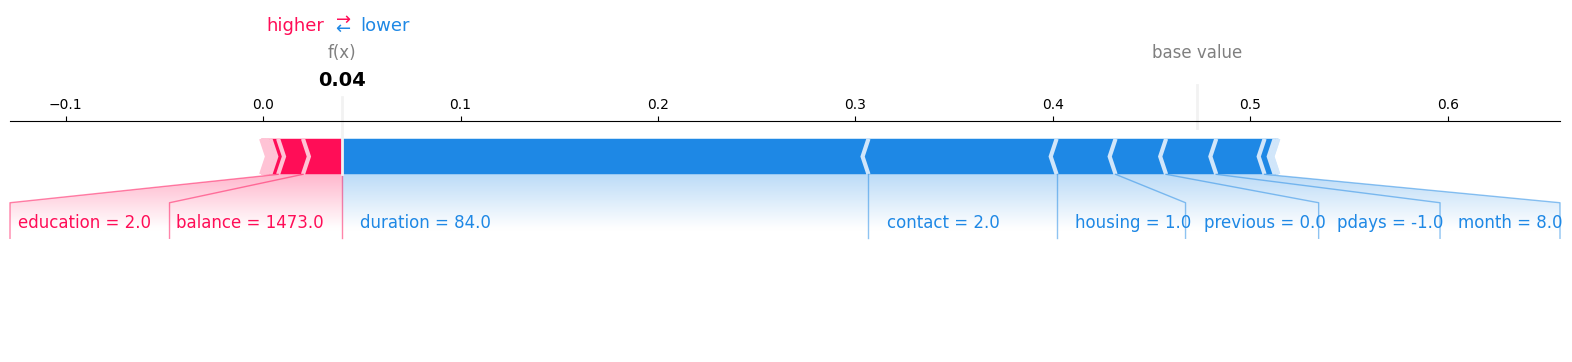

In [47]:
for i in range(5):
    print(f"\n🔎 Explanation for Prediction {i+1}")

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_test.iloc[i],
        matplotlib=True
    )